# Zomato Reviews — Sentiment & Complaint Analysis

**Goal:** go beyond the star rating and mine the actual review text to find:
1. Where sentiment and star rating disagree (mismatch = interesting signal)
2. What people are actually complaining about at low-rated restaurants
3. A sentiment score we could later feed into a predictive model

Data: `data/processed/zomato_clean.csv`


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

df = pd.read_csv("../data/processed/zomato_clean.csv")
df = df[df["review_text_combined"].notna() & (df["review_text_combined"].str.len() > 0)]
print(f"{len(df):,} restaurants have review text to analyze")
df[["name", "rate", "review_count_parsed", "review_text_combined"]].head()


8,888 restaurants have review text to analyze


,name,rate,review_count_parsed,review_text_combined
0,Byg Brewski Brewing Company,4.9,639,This is an absolute great place. The service i...
1,Toit,4.7,71,The crowd keeps flowing in and out at Toit. It...
2,Truffles,4.7,424,Not bad but the burgers didn't match my expect...
3,Ab'S - Absolute Barbecues,4.8,266,We came here for a team dinner. Quite big plac...
4,The Black Pearl,4.7,415,Amazing experience amazing food. I have never ...


## 1. Set up sentiment analysis (VADER)
VADER is a lexicon-based sentiment tool tuned for informal text like reviews — good fit here, and fast enough to run on thousands of rows without a GPU.

In [2]:
import nltk
nltk.download("vader_lexicon", quiet=True)
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

# Quick sanity check
print(sia.polarity_scores("The food was amazing and the service was excellent!"))
print(sia.polarity_scores("Terrible experience, cold food and rude staff."))


{'neg': 0.0, 'neu': 0.473, 'pos': 0.527, 'compound': 0.8313}
{'neg': 0.55, 'neu': 0.45, 'pos': 0.0, 'compound': -0.7269}


## 2. Score every restaurant's combined review text
The `compound` score ranges from -1 (very negative) to +1 (very positive). We'll compute this per restaurant using its combined review text.

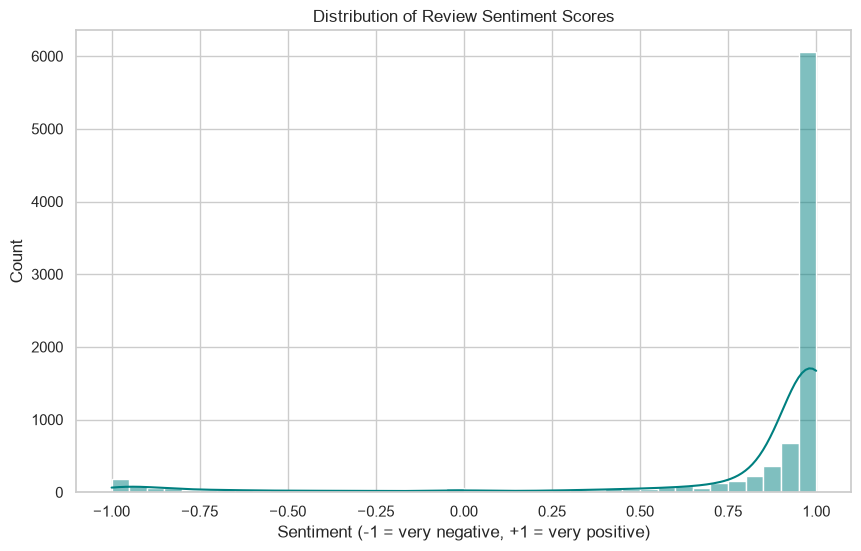

count    8888.000000
mean        0.795769
std         0.479833
min        -0.999700
25%         0.907325
50%         0.989300
75%         0.998725
max         0.999900
Name: sentiment_score, dtype: float64

In [3]:
def get_sentiment(text, max_chars=5000):
    # Truncate very long combined review text for speed; VADER doesn't need
    # the full text to get a stable estimate
    text = str(text)[:max_chars]
    return sia.polarity_scores(text)["compound"]

df["sentiment_score"] = df["review_text_combined"].apply(get_sentiment)

plt.figure(figsize=(10, 6))
sns.histplot(df["sentiment_score"], bins=40, color="teal", kde=True)
plt.title("Distribution of Review Sentiment Scores")
plt.xlabel("Sentiment (-1 = very negative, +1 = very positive)")
plt.show()

df["sentiment_score"].describe()


## 3. Does sentiment agree with star rating?
If reviews were perfectly consistent with star ratings, this scatter would show a clean upward line. Deviations from that line are the interesting part.

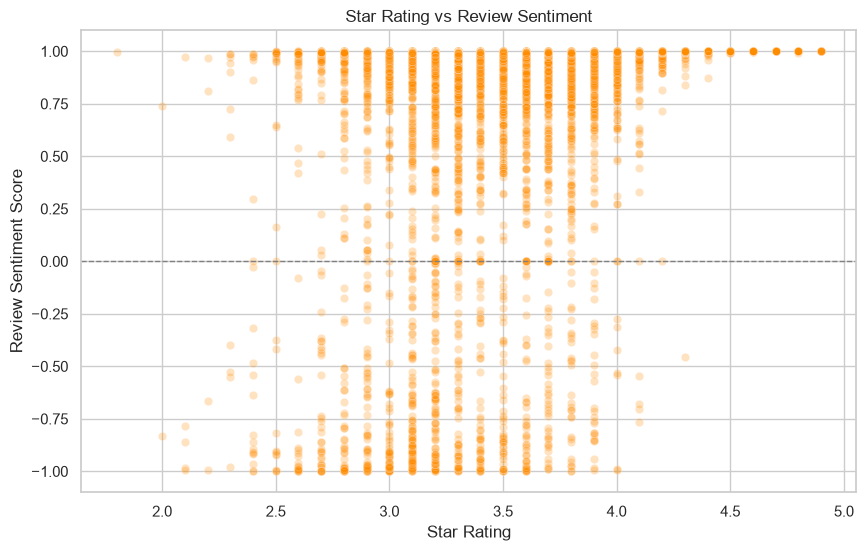

Correlation between star rating and review sentiment: 0.363


In [4]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="rate", y="sentiment_score", alpha=0.25, color="darkorange")
plt.title("Star Rating vs Review Sentiment")
plt.xlabel("Star Rating")
plt.ylabel("Review Sentiment Score")
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.show()

corr = df[["rate", "sentiment_score"]].corr().iloc[0, 1]
print(f"Correlation between star rating and review sentiment: {corr:.3f}")


## 4. Finding the mismatches
The most interesting restaurants are the ones where star rating and review sentiment disagree — e.g. a decent star rating (3.5-4) but genuinely negative review text, or vice versa. These are the restaurants worth digging into.

In [5]:
# Normalize rate to the same -1..1-ish scale roughly for comparison purposes
# (rate is 1-5, so we rescale to -1..1 to compare against sentiment_score)
df["rate_scaled"] = (df["rate"] - 3) / 2  # centers around 3-star = 0

df["mismatch"] = df["sentiment_score"] - df["rate_scaled"]

# Restaurants where the star rating looks better than the actual review sentiment
rating_overstated = df.sort_values("mismatch").head(15)
print("Restaurants where star rating looks BETTER than what reviews actually say:")
rating_overstated[["name", "location", "rate", "sentiment_score", "votes"]]


Restaurants where star rating looks BETTER than what reviews actually say:


,name,location,rate,sentiment_score,votes
1774,Royal Calcutta Restaurant,Koramangala 1st Block,4.0,-0.9918,270
518,Panchavati Gaurav Thali,Brigade Road,4.0,-0.9883,930
665,Domino'S Pizza,Basavanagudi,3.9,-0.9916,770
1271,Godavari Delights,Electronic City,3.9,-0.9827,407
1787,Donne Biriyani Angadi Mane,Rajajinagar,3.8,-0.9997,268
2940,Hotel New Karavali,Banashankari,3.8,-0.9988,133
2481,Papanna'S Biriyani,Basaveshwara Nagar,3.9,-0.9413,175
4257,The Bong Palate,BTM,3.8,-0.9751,64
1446,Bihar Ki Shan,HSR,3.8,-0.9746,351
1788,Agarwal Food Service,Bannerghatta Road,3.8,-0.9577,268


In [6]:
# Restaurants where reviews are more positive than the star rating suggests
rating_understated = df.sort_values("mismatch", ascending=False).head(15)
print("Restaurants where reviews are MORE POSITIVE than the star rating suggests:")
rating_understated[["name", "location", "rate", "sentiment_score", "votes"]]


Restaurants where reviews are MORE POSITIVE than the star rating suggests:


,name,location,rate,sentiment_score,votes
2058,Alibi - Maya International Hotel,Church Street,1.8,0.9983,225
2314,Madurai Idly Shop,Sarjapur Road,2.1,0.9732,193
1610,Pizza Hut,Marathahalli,2.2,0.9699,310
3118,Bhagini,Banaswadi,2.3,0.9880,120
2473,Mast Kalandar,JP Nagar,2.3,0.9863,176
1958,Meghana Biryani,Bellandur,2.3,0.9707,240
2429,Vande Matharam,Rajajinagar,2.3,0.9420,180
3505,Zaika Take Away,Bannerghatta Road,2.4,0.9875,96
1313,Ammi'S Biryani,Bannerghatta Road,2.4,0.9850,392
1577,Lazeez,Koramangala 1st Block,2.4,0.9784,318


## 5. What are people actually complaining about?
For restaurants with low sentiment scores, let's pull out the most common complaint words/phrases. This is the qualitative payoff — turning star ratings into an actual diagnosis.

697 restaurants have net-negative review sentiment
8011 restaurants have strongly positive review sentiment (baseline)


C:\Users\Anushka Ghat\AppData\Local\Temp\ipykernel_10952\3962163321.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_complaint_words, x="lift", y="word", palette="Reds_r")


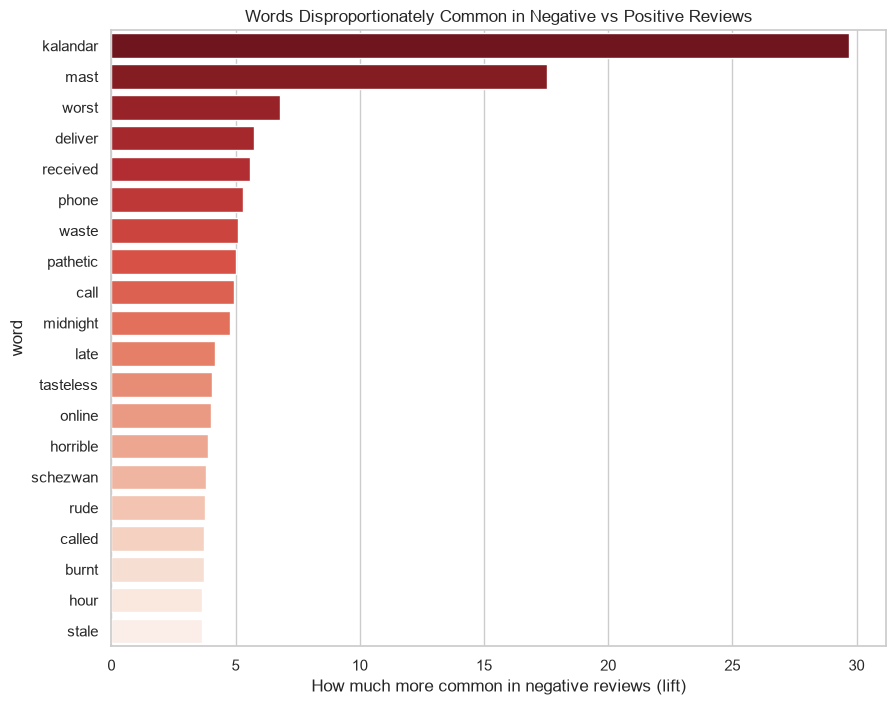

,word,neg_count,pos_count,lift
157,kalandar,401,217,29.716722
145,mast,428,393,17.549331
2,worst,3132,7445,6.795349
36,deliver,977,2756,5.724938
79,received,630,1825,5.573818
295,phone,234,711,5.309442
71,waste,658,2091,5.081328
30,pathetic,1051,3371,5.035333
51,call,756,2483,4.916808
248,midnight,280,943,4.791804


In [7]:
STOPWORDS = set("""the a an is was were are and or but to of in on at for with this that
it its as be been being have has had do does did not no so very good great nice place
food we i they he she you your our their good the and here there which just will really
even also like ordered order from delivered delivery quantity restaurant chicken rice
biryani time""".split())

def extract_words(text):
    words = re.findall(r"[a-z]+", str(text).lower())
    return [w for w in words if w not in STOPWORDS and len(w) > 3]

negative_restaurants = df[df["sentiment_score"] < -0.1]
positive_restaurants = df[df["sentiment_score"] > 0.3]
print(f"{len(negative_restaurants)} restaurants have net-negative review sentiment")
print(f"{len(positive_restaurants)} restaurants have strongly positive review sentiment (baseline)")

def word_freq(rows, col="review_text_combined", top_n=2000):
    words = []
    for text in rows[col]:
        words.extend(extract_words(text))
    return Counter(words)

neg_counts = word_freq(negative_restaurants)
pos_counts = word_freq(positive_restaurants)

# Normalize by total words in each group so we compare rates, not raw counts
neg_total = sum(neg_counts.values())
pos_total = sum(pos_counts.values())

rows = []
for word, neg_c in neg_counts.most_common(300):
    if neg_c < 30:
        continue
    pos_c = pos_counts.get(word, 0)
    neg_rate = neg_c / neg_total
    pos_rate = (pos_c + 1) / pos_total  # +1 smoothing avoids divide-by-zero
    lift = neg_rate / pos_rate
    rows.append((word, neg_c, pos_c, lift))

lift_df = pd.DataFrame(rows, columns=["word", "neg_count", "pos_count", "lift"])
top_complaint_words = lift_df.sort_values("lift", ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(data=top_complaint_words, x="lift", y="word", palette="Reds_r")
plt.title("Words Disproportionately Common in Negative vs Positive Reviews")
plt.xlabel("How much more common in negative reviews (lift)")
plt.show()

top_complaint_words


**Interpretation:** words like `slow`, `cold`, `rude`, `wait`, `expensive`, `packaging` (if they show up) point to specific, fixable operational issues — not vague dissatisfaction. This is a much more actionable finding than "low rating" alone, and it's the kind of insight a business could actually act on.

## 6. Cross-check against the earlier 'problem restaurants' list
Recall from the EDA notebook: restaurants with high votes but rate < 3.5 were flagged as a real service signal. Let's see what their review sentiment says.

In [8]:
problem_restaurants = df[(df["votes"] > df["votes"].quantile(0.75)) & (df["rate"] < 3.5)]
problem_restaurants = problem_restaurants.sort_values("votes", ascending=False)

print(f"{len(problem_restaurants)} high-visibility, low-rating restaurants")
print(f"Their average sentiment score: {problem_restaurants['sentiment_score'].mean():.3f}")
print(f"Compared to overall average sentiment: {df['sentiment_score'].mean():.3f}")

problem_restaurants[["name", "location", "rate", "votes", "sentiment_score"]].head(15)


210 high-visibility, low-rating restaurants
Their average sentiment score: 0.608
Compared to overall average sentiment: 0.796


,name,location,rate,votes,sentiment_score
219,Moriz Restaurant,Brookefield,2.8,1884,0.9480
332,Moriz Restaurant,Electronic City,3.1,1365,0.9996
527,Delhi Food Point,Koramangala 1st Block,3.3,912,0.9646
529,Lazeez,Koramangala 5th Block,3.1,911,0.9977
592,Freshmenu,Whitefield,3.2,835,0.9864
594,Savoury Restaurant,Sarjapur Road,2.9,833,0.9963
619,M.M.A. Kabab'S & Biriyani Center,Brookefield,3.3,802,0.9979
724,Biriyani Nights,New BEL Road,3.2,713,-0.9976
755,Moriz Restaurant,Marathahalli,3.2,684,0.9997
785,Kfc,Indiranagar,3.1,668,0.9533


## Summary of findings
*(Fill this in with your actual numbers once you run this notebook)*

- Correlation between star rating and review sentiment: ...
- Number of restaurants where rating and sentiment clearly disagree: ...
- Top complaint themes found in negative reviews: ...
- Do the "high votes, low rating" restaurants also show negative sentiment (confirming it's a real problem, not just harsh scoring)? ...

## Next steps
- Predictive model: use `sentiment_score`, `cost_for_two`, `cuisines`, `location`, `book_table` etc. to predict rating bucket
- Feature importance to state precisely what drives ratings, backed by the model
